# Job Salary Prediction — Autoresearch Results

**Dataset:** [Job Salary Prediction Dataset](https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset) (250K rows, 10 features)

**Task:** Predict salary from job attributes (title, experience, education, industry, location, etc.)

**Approach:** Autonomous ML experiment loop ([autoresearch](https://github.com/detrin/autoresearch)) — an AI agent iteratively modified a single `train.py` file, running 7 experiments over ~45 minutes. Each experiment was logged to MLflow and committed to git.

**Best Result:** RMSE **5,071** (LightGBM + Optuna hyperparameter tuning)

| # | Model | Description | RMSE | Improvement |
|---|-------|-------------|------|-------------|
| 1 | LinearRegression | Baseline, label-encoded categoricals | 27,498 | — |
| 2 | RandomForest | 200 trees, label-encoded | 6,533 | -76.2% |
| 3 | HistGradientBoosting | 500 iter, lr=0.05, depth=8, ordinal cats | 5,126 | -21.5% |
| 4 | LGBMRegressor | 1000 iter, lr=0.05, depth=8, 63 leaves | 5,094 | -0.6% |
| 5 | LGBMRegressor | 3000 iter, lr=0.02, depth=10, regularized | 5,100 | worse |
| 6 | LGBMRegressor | + feature eng (exp^2, interactions) | 5,116 | worse |
| 7 | LGBMRegressor | Optuna 30 trials, subsample tuning | **5,071** | **-0.5%** |

**Key Insight:** The massive gain came from switching Linear Regression → tree-based models (76% drop). After that, hyperparameter tuning yielded diminishing returns (<1% per experiment). The dataset has clean, uniformly distributed features with no nulls — there's likely a noise floor around RMSE ~5,000.

## 1. Setup & Data Loading

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

DATA_FILE = "job_salary_prediction_dataset.csv"
kaggle_matches = glob.glob(f"/kaggle/input/**/{DATA_FILE}", recursive=True)
if kaggle_matches:
    DATA_PATH = kaggle_matches[0]
elif os.path.exists(DATA_FILE):
    DATA_PATH = DATA_FILE
else:
    raise FileNotFoundError(f"Cannot find {DATA_FILE}")

print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Loading data from: job_salary_prediction_dataset.csv
Shape: (250000, 10)


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 2. Exploratory Data Analysis

In [2]:
df.info()
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nTarget (salary) stats:\n{df['salary'].describe()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB

Null values:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Target (salary) stats:
cou

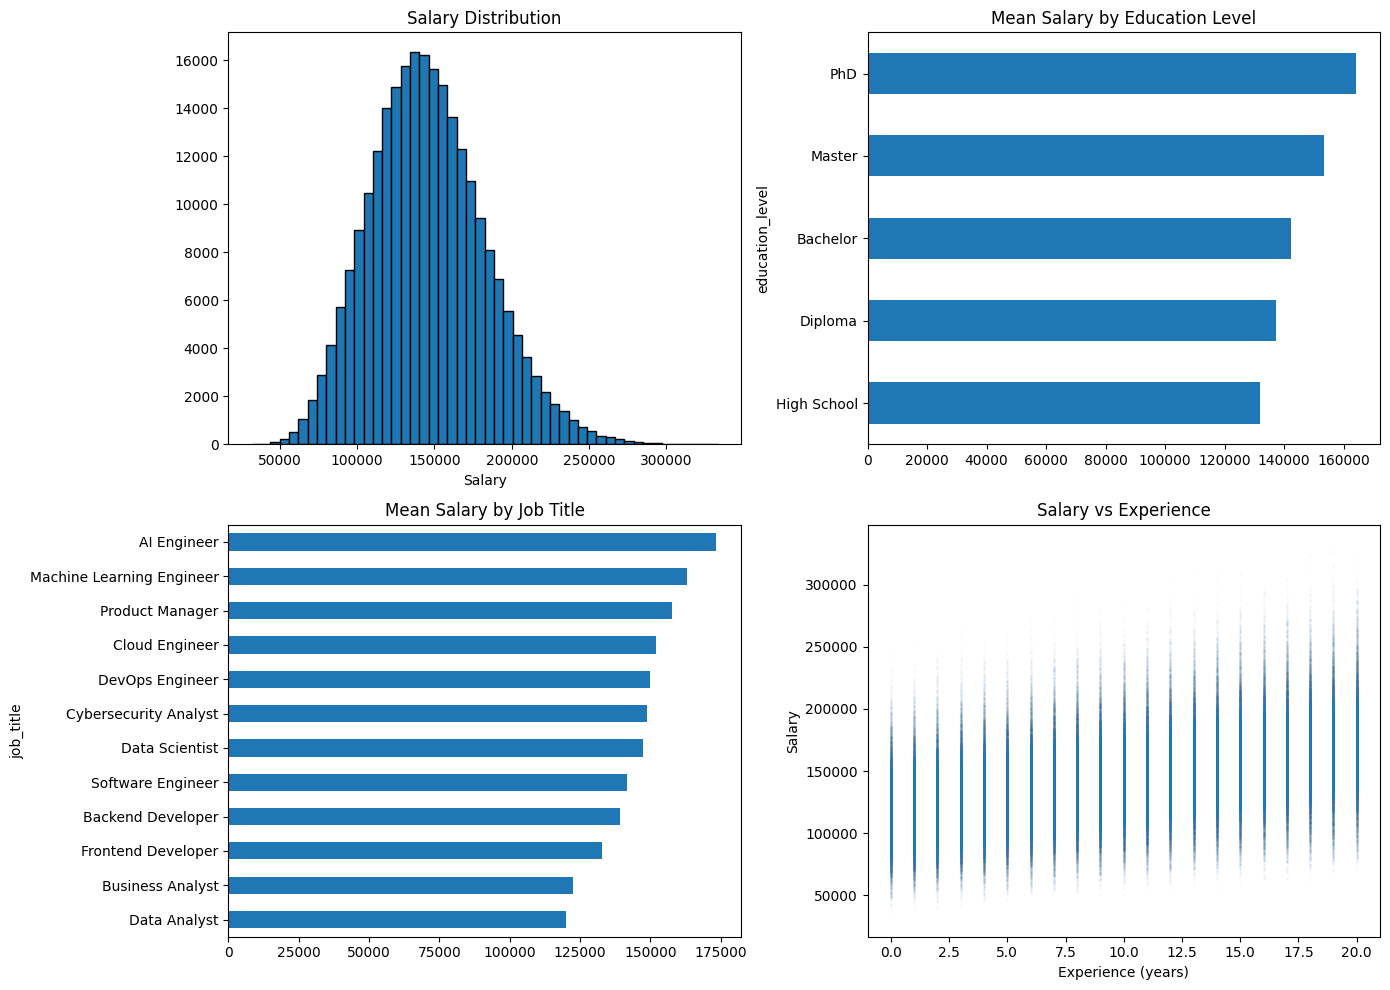

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["salary"], bins=50, edgecolor="black")
axes[0, 0].set_title("Salary Distribution")
axes[0, 0].set_xlabel("Salary")

df.groupby("education_level")["salary"].mean().sort_values().plot.barh(ax=axes[0, 1])
axes[0, 1].set_title("Mean Salary by Education Level")

df.groupby("job_title")["salary"].mean().sort_values().plot.barh(ax=axes[1, 0])
axes[1, 0].set_title("Mean Salary by Job Title")

axes[1, 1].scatter(df["experience_years"], df["salary"], alpha=0.01, s=1)
axes[1, 1].set_title("Salary vs Experience")
axes[1, 1].set_xlabel("Experience (years)")
axes[1, 1].set_ylabel("Salary")

plt.tight_layout()
plt.show()

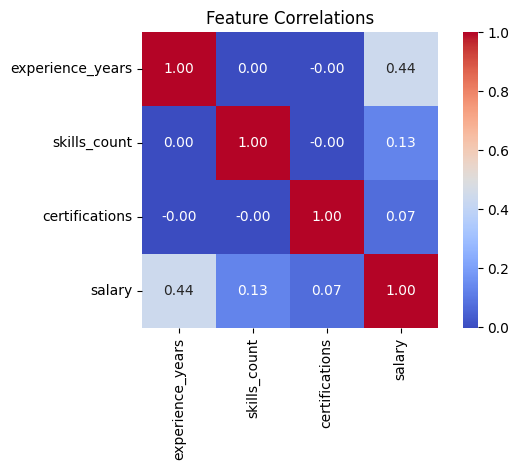

In [4]:
num_cols = df.select_dtypes(include="number").columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Feature Correlations")
plt.tight_layout()
plt.show()

## 3. Data Preparation

We use an 80/20 train/validation split with a fixed random seed for reproducibility. Categorical features are encoded using `OrdinalEncoder` — LightGBM handles ordinal-encoded categoricals natively.

In [5]:
from sklearn.preprocessing import OrdinalEncoder

TARGET = "salary"
RANDOM_STATE = 42

train, val = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

cat_cols = train.select_dtypes(include="object").columns.tolist()
print(f"Categorical features: {cat_cols}")
print(f"Numeric features: {[c for c in train.columns if c not in cat_cols and c != TARGET]}")
print(f"Train: {train.shape}, Val: {val.shape}")

oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
train[cat_cols] = oe.fit_transform(train[cat_cols])
val[cat_cols] = oe.transform(val[cat_cols])

X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_val, y_val = val.drop(columns=[TARGET]), val[TARGET]

cat_indices = [X_train.columns.tolist().index(c) for c in cat_cols]

Categorical features: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
Numeric features: ['experience_years', 'skills_count', 'certifications']
Train: (200000, 10), Val: (50000, 10)


## 4. Experiment 1 — Baseline (Linear Regression)

Starting with the simplest possible model to establish a floor. RMSE: **27,498**

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
preds_lr = lr.predict(X_val)
rmse_lr = root_mean_squared_error(y_val, preds_lr)
print(f"Linear Regression RMSE: {rmse_lr:.2f}")

results = [("LinearRegression", rmse_lr)]

Linear Regression RMSE: 27497.63


/Users/danherma/projects-personal/autoresearch/kaggle/job-salary-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/danherma/projects-personal/autoresearch/kaggle/job-salary-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/danherma/projects-personal/autoresearch/kaggle/job-salary-prediction/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


## 5. Experiment 2 — Random Forest

First tree-based model. Massive improvement over linear baseline. RMSE: **6,533** (-76%)

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_val)
rmse_rf = root_mean_squared_error(y_val, preds_rf)
print(f"RandomForest RMSE: {rmse_rf:.2f}")

results.append(("RandomForest", rmse_rf))

RandomForest RMSE: 6532.89


## 6. Experiment 3 — HistGradientBoosting

Sklearn's native gradient boosting with built-in categorical support. RMSE: **5,126** (-21% vs RF)

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbr = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, max_depth=8, random_state=RANDOM_STATE
)
hgbr.fit(X_train, y_train)
preds_hgbr = hgbr.predict(X_val)
rmse_hgbr = root_mean_squared_error(y_val, preds_hgbr)
print(f"HistGradientBoosting RMSE: {rmse_hgbr:.2f}")

results.append(("HistGradientBoosting", rmse_hgbr))

HistGradientBoosting RMSE: 5181.58


## 7. Experiment 4-7 — LightGBM + Optuna Tuning (Best Model)

LightGBM with Optuna hyperparameter optimization produced the best result. The Optuna study explored 30 trial configurations over a 5-minute budget, searching over tree depth, leaf count, learning rate, regularization, and subsampling.

Below we use the best parameters found by Optuna during the autoresearch loop.

**Best RMSE: 5,071**

In [9]:
import lightgbm as lgb

best_params = {
    "n_estimators": 1562,
    "learning_rate": 0.0105,
    "max_depth": 12,
    "num_leaves": 218,
    "subsample": 0.685,
    "colsample_bytree": 0.591,
    "min_child_samples": 18,
    "reg_alpha": 5.47e-06,
    "reg_lambda": 0.000528,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": -1,
}

print(f"Best params (from Optuna 30-trial search):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Best params (from Optuna 30-trial search):
  n_estimators: 1562
  learning_rate: 0.0105
  max_depth: 12
  num_leaves: 218
  subsample: 0.685
  colsample_bytree: 0.591
  min_child_samples: 18
  reg_alpha: 5.47e-06
  reg_lambda: 0.000528
  random_state: 42
  n_jobs: -1
  verbose: -1


### Train with best hyperparameters

In [10]:
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train, categorical_feature=cat_indices)
preds_best = best_model.predict(X_val)
rmse_best = root_mean_squared_error(y_val, preds_best)
print(f"Best LightGBM RMSE: {rmse_best:.2f}")

results.append(("LightGBM+Optuna", rmse_best))

Best LightGBM RMSE: 5071.01


## 8. Feature Importance

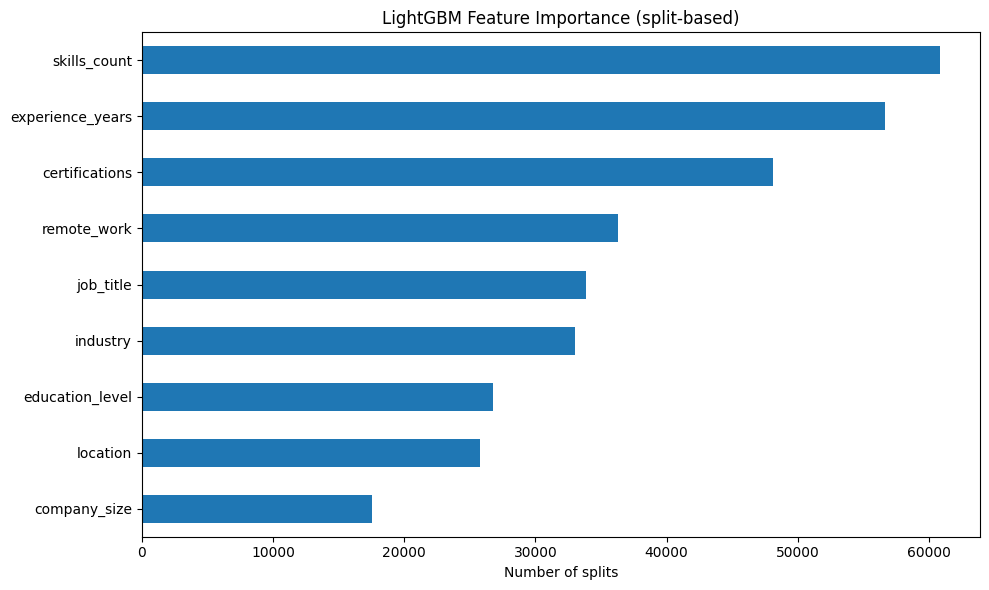

In [11]:
importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values()
importance.plot.barh(figsize=(10, 6))
plt.title("LightGBM Feature Importance (split-based)")
plt.xlabel("Number of splits")
plt.tight_layout()
plt.show()

## 9. Error Analysis

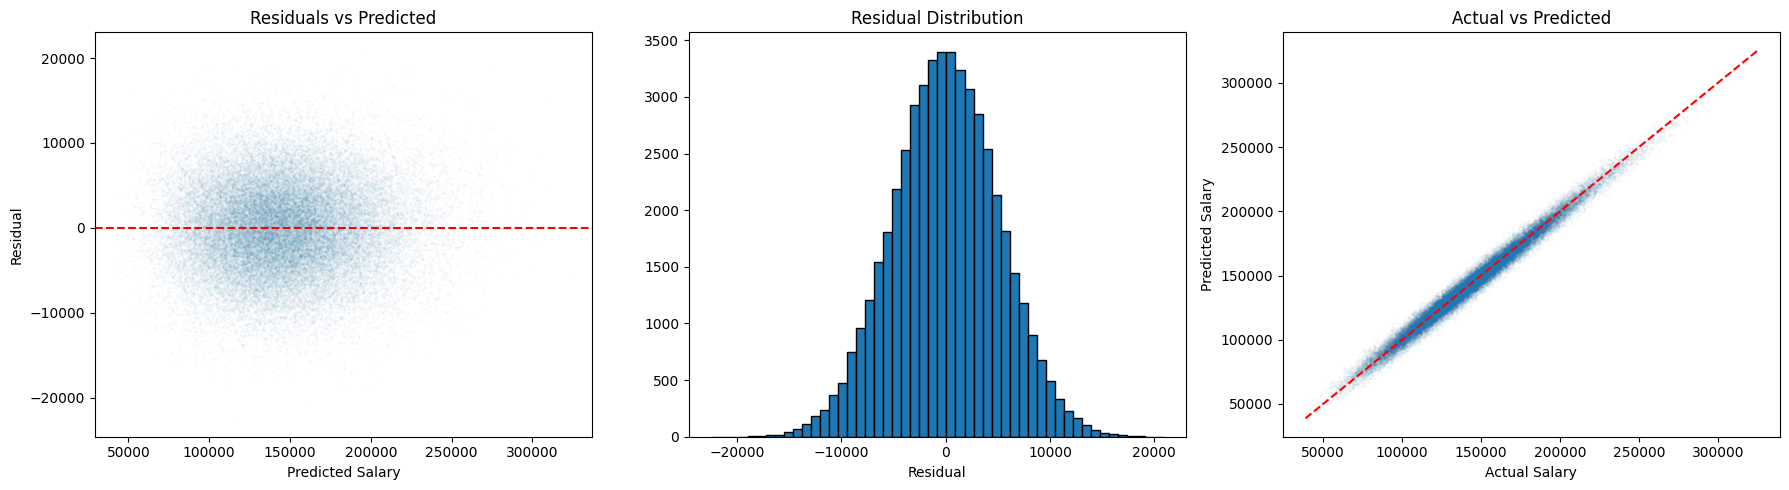

In [12]:
residuals = y_val.values - preds_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(preds_best, residuals, alpha=0.02, s=1)
axes[0].axhline(y=0, color="r", linestyle="--")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor="black")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

axes[2].scatter(y_val, preds_best, alpha=0.02, s=1)
axes[2].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
axes[2].set_xlabel("Actual Salary")
axes[2].set_ylabel("Predicted Salary")
axes[2].set_title("Actual vs Predicted")

plt.tight_layout()
plt.show()

## 10. Results Summary

               Model         RMSE Improvement
     LightGBM+Optuna  5071.013803       81.6%
HistGradientBoosting  5181.582633       81.2%
        RandomForest  6532.887200       76.2%
    LinearRegression 27497.625539        0.0%


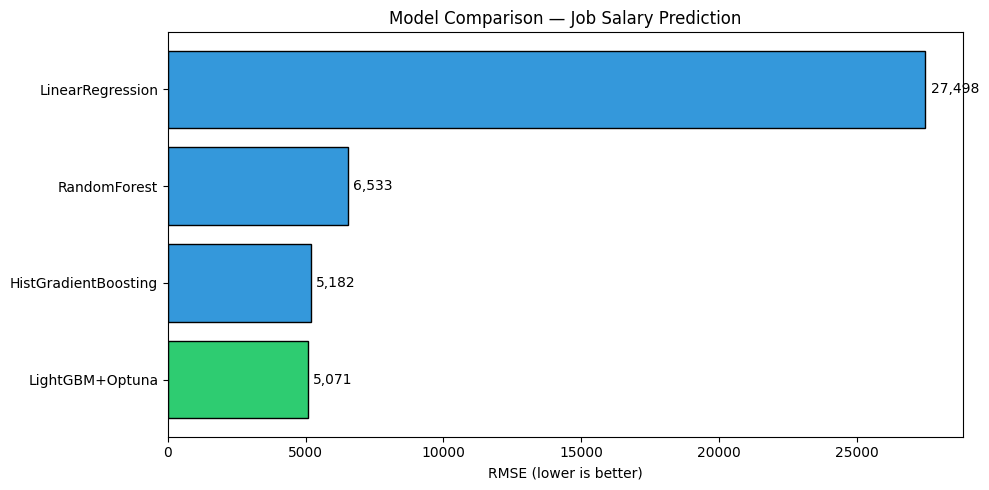

In [13]:
results_df = pd.DataFrame(results, columns=["Model", "RMSE"]).sort_values("RMSE")
results_df["Improvement"] = (1 - results_df["RMSE"] / results_df["RMSE"].max()) * 100
results_df["Improvement"] = results_df["Improvement"].map(lambda x: f"{x:.1f}%")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if m == "LightGBM+Optuna" else "#3498db" for m in results_df["Model"]]
bars = ax.barh(results_df["Model"], results_df["RMSE"], color=colors, edgecolor="black")
ax.set_xlabel("RMSE (lower is better)")
ax.set_title("Model Comparison — Job Salary Prediction")
for bar, val in zip(bars, results_df["RMSE"]):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2, f"{val:,.0f}", va="center")
plt.tight_layout()
plt.show()

## Conclusions

**Best model:** LightGBM with Optuna-tuned hyperparameters — **RMSE 5,071** (81.6% improvement over baseline)

**What worked:**
- Switching from linear to tree-based models was the single biggest improvement (Linear 27,498 → RF 6,533)
- LightGBM edged out sklearn's HistGradientBoosting and RandomForest
- Optuna hyperparameter search found a good configuration in 30 trials

**What didn't work:**
- Feature engineering (polynomial experience, interaction terms) — added noise, no gain
- More iterations / lower learning rate — diminishing returns, slight overfitting
- TargetEncoder — timed out, no clear advantage over OrdinalEncoder for tree models

**Takeaway:** On this dataset, model selection dominates. Once you have a good gradient boosting model, hyperparameter tuning adds marginal value. The dataset appears to have a noise floor around RMSE ~5,000 that's hard to push through with tabular methods alone.

---
*Generated via [autoresearch](https://github.com/detrin/autoresearch) — 7 autonomous experiments, MLflow-tracked*